# Vision Transformer B16

In [1]:
import torch
import time
from models import load_model2

In [2]:
torch.cuda.is_available()

True

In [3]:
if torch.cuda.is_available() : 
    torch.cuda.empty_cache()
dev_name = torch.cuda.get_device_name(0)
print(f"Using device: {dev_name}")


Using device: NVIDIA GeForce RTX 3050 Laptop GPU


In [4]:
px = 224
model = load_model2(device="cuda")
x = torch.randn(1,3,px,px) 

t0 = torch.cuda.Event(enable_timing=True)
t1 = torch.cuda.Event(enable_timing=True)
t0.record()
y = x.to("cuda") # but will this move to gpu by deleteing the cpu model? we will see
t1.record()
print(f"Time taken to move input to GPU: {t0.elapsed_time(t1):.2f} ms")
torch.cuda.synchronize()

model.eval() 

t0 = torch.cuda.Event(enable_timing=True)
t1 = torch.cuda.Event(enable_timing=True)
t0.record()
model(y)
t1.record()
torch.cuda.synchronize()

# inference on cpu, without cuda
model_cpu = load_model2(device="cpu")
model_cpu.eval()

t0_cpu = time.perf_counter()
model_cpu(x)
t1_cpu = time.perf_counter()

print(f"Inference time on CPU: {(t1_cpu - t0_cpu)*1000:.2f} ms")
print(f"Inference time on GPU: {t0.elapsed_time(t1):.2f} ms")

Time taken to move input to GPU: 0.28 ms
Inference time on CPU: 265.66 ms
Inference time on GPU: 388.43 ms


In [5]:
import torch
import torch.nn as nn
import pandas as pd
import time
import matplotlib.pyplot as plt


############################################
# FLOP estimation
############################################

def compute_flops(layer, inp, out):

    if isinstance(layer, nn.Conv2d):
        batch = inp[0].shape[0]
        out_c, out_h, out_w = out.shape[1:]
        kernel_ops = layer.kernel_size[0] * layer.kernel_size[1] * layer.in_channels
        return batch * out_c * out_h * out_w * kernel_ops

    elif isinstance(layer, nn.Linear):
        batch = inp[0].shape[0]
        return batch * layer.in_features * layer.out_features

    elif isinstance(layer, (nn.ReLU, nn.BatchNorm2d)):
        return inp[0].numel()

    return 0


############################################
# Device-aware profiler
############################################

def profile_model(model, x, device="cuda"):

    model = model.to(device)
    x = x.to(device)

    model.eval()

    records = []
    hooks = []
    start_times = {}

    layer_id = 0


    ########################################
    # Hook registration
    ########################################

    def register_hooks(module):

        nonlocal layer_id

        if len(list(module.children())) > 0:
            return

        idx = layer_id
        layer_id += 1


        ####################################
        # pre hook → start timer
        ####################################
        def pre_hook(module, inp):

            if device == "cuda":
                torch.cuda.synchronize()

            start_times[id(module)] = time.perf_counter()


        ####################################
        # post hook → stop timer
        ####################################
        def post_hook(module, inp, out):

            if device == "cuda":
                torch.cuda.synchronize()

            end = time.perf_counter()

            elapsed = (end - start_times[id(module)]) * 1000

            params = sum(p.numel() for p in module.parameters())

            activations = out.numel()

            flops = compute_flops(module, inp, out)

            records.append({
                "layer": idx,
                "name": module.__class__.__name__,
                "params": params,
                "activations": activations,
                "activation_MB": activations * 4 / (1024**2),
                "flops": flops,
                "time_ms": elapsed
            })


        hooks.append(module.register_forward_pre_hook(pre_hook))
        hooks.append(module.register_forward_hook(post_hook))


    model.apply(register_hooks)


    ########################################
    # Forward pass
    ########################################

    with torch.no_grad():
        model(x)

    for h in hooks:
        h.remove()


    ########################################
    # DataFrame
    ########################################

    df = pd.DataFrame(records)

    df = df.sort_values("layer")

    df["cum_params"] = df.params.cumsum()
    df["cum_flops"] = df.flops.cumsum()
    df["cum_time"] = df.time_ms.cumsum()
    df["cum_activation_MB"] = df.activation_MB.cumsum()

    return df


############################################
# Plot comparison
############################################

def plot_cpu_gpu_comparison(df_cpu, df_gpu):

    n = min(len(df_cpu), len(df_gpu))

    df_cpu = df_cpu.iloc[:n]
    df_gpu = df_gpu.iloc[:n]

    layers = df_cpu["layer"]

    fig, ax = plt.subplots(2,3, figsize=(16,8))


    ####################################
    # Params
    ####################################
    ax[0,0].bar(layers, df_cpu.params)
    ax[0,0].set_title("Params / Layer")


    ####################################
    # Activations
    ####################################
    ax[0,1].bar(layers, df_cpu.activation_MB)
    ax[0,1].set_title("Activation Size (MB)")


    ####################################
    # FLOPs
    ####################################
    ax[0,2].bar(layers, df_cpu.flops)
    ax[0,2].set_title("FLOPs / Layer")


    ####################################
    # Runtime
    ####################################
    width = 0.4

    ax[1,0].bar(layers-width/2, df_cpu.time_ms, width, label="CPU")
    ax[1,0].bar(layers+width/2, df_gpu.time_ms, width, label="GPU")

    ax[1,0].set_title("Runtime / Layer (ms)")
    ax[1,0].legend()


    ####################################
    # Cumulative FLOPs
    ####################################
    ax[1,1].plot(layers, df_cpu.cum_flops, label="CPU")
    ax[1,1].plot(layers, df_gpu.cum_flops, label="GPU")

    ax[1,1].set_title("Cumulative FLOPs")
    ax[1,1].legend()


    ####################################
    # Cumulative Runtime
    ####################################
    ax[1,2].plot(layers, df_cpu.cum_time, label="CPU")
    ax[1,2].plot(layers, df_gpu.cum_time, label="GPU")

    ax[1,2].set_title("Cumulative Runtime (ms)")
    ax[1,2].legend()


    for axis in ax.flat:
        axis.set_xlabel("Layer")


    plt.tight_layout()
    plt.show()

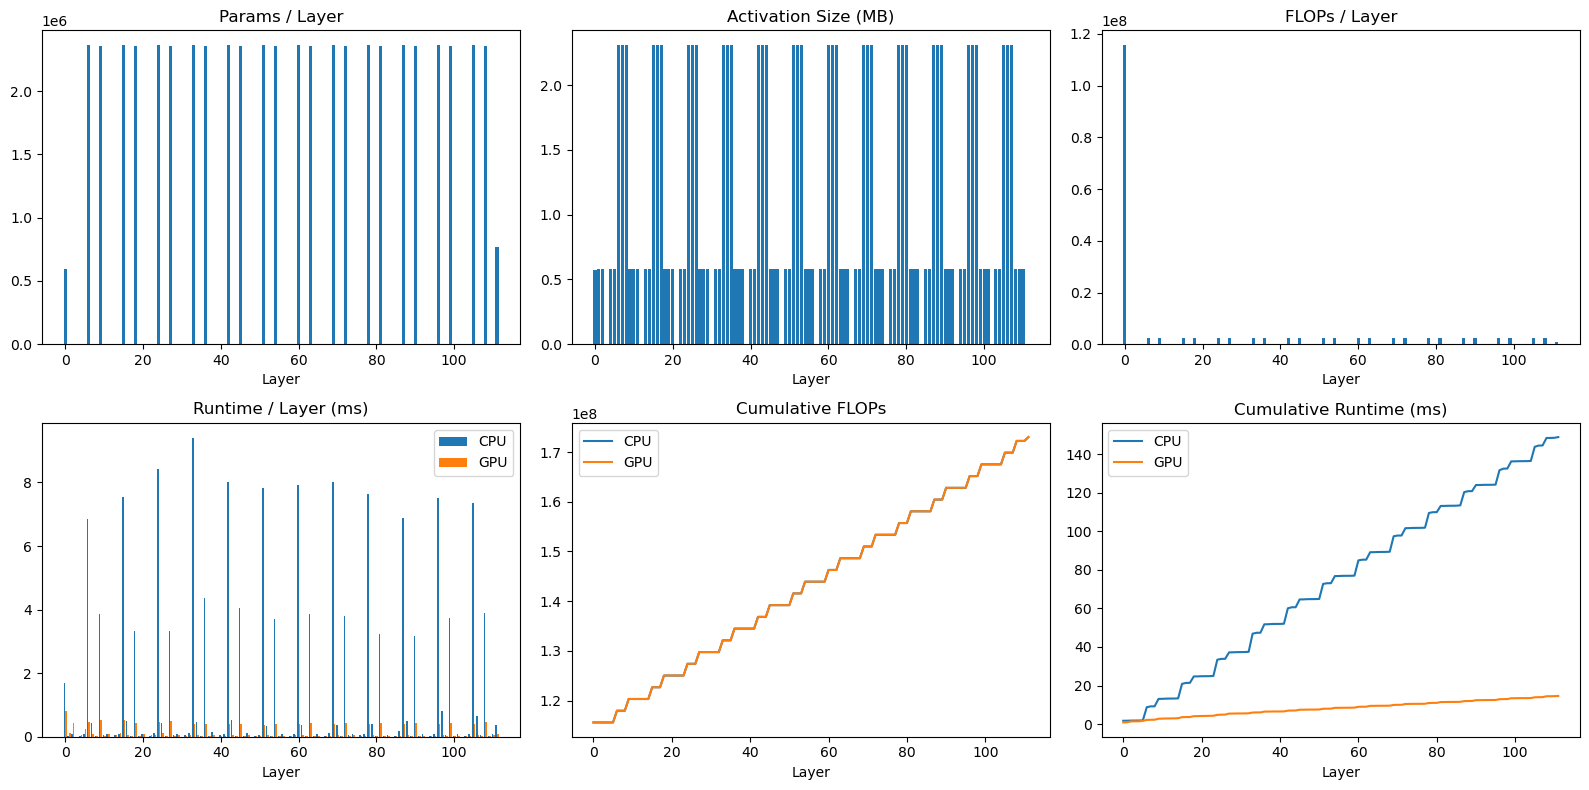

In [6]:
df_gpu = profile_model(model, y, device="cuda")
df_cpu = profile_model(model, y, device="cpu")
plot_cpu_gpu_comparison(df_cpu, df_gpu)

In [7]:
print(torch.cuda.get_device_name(0))

NVIDIA GeForce RTX 3050 Laptop GPU


In [8]:
import pandas as pd
import matplotlib.pyplot as plt


def compute_comm_time(df, bandwidth_MBps, plot=True):
    """
    df: dataframe from profiler
    bandwidth_MBps: network bandwidth in MB/s
    """

    df_comm = df.copy()

    # communication time (ms)
    df_comm["comm_time_ms"] = (df_comm["activation_MB"] / bandwidth_MBps) * 1000

    if plot:

        plt.figure(figsize=(10,5))

        plt.plot(df_comm["layer"], df_comm["comm_time_ms"])

        plt.xlabel("Split Layer")
        plt.ylabel("Communication Time (ms)")
        plt.title("Communication Time vs Split Layer")

        plt.grid(True)

        plt.show()

    return df_comm

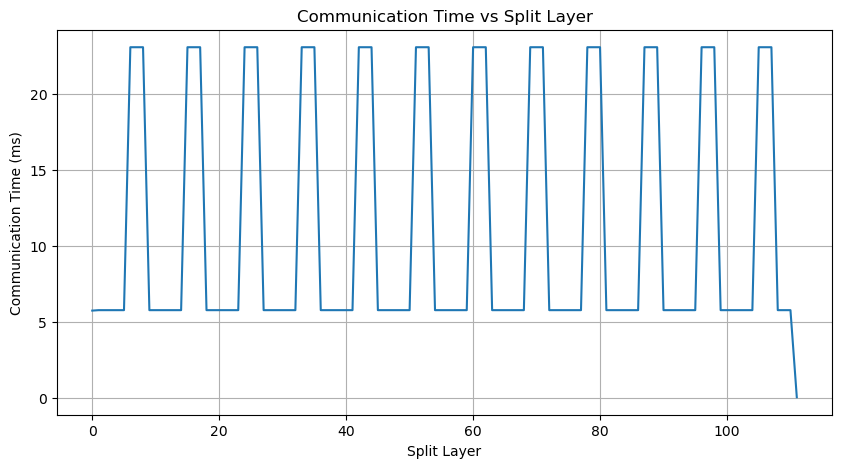

In [9]:
BW = 100  # MB/s

df_comm = compute_comm_time(df_gpu, BW)

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def split_latency_analysis(df_cpu, df_gpu, bandwidth_MBps, plot=True):

    # align lengths
    n = min(len(df_cpu), len(df_gpu))
    df_cpu = df_cpu.iloc[:n].copy()
    df_gpu = df_gpu.iloc[:n].copy()

    layers = df_cpu["layer"].values

    ########################################
    # CPU cumulative time (first k layers)
    ########################################

    T_cpu = df_cpu["cum_time"].values

    ########################################
    # GPU remaining time (k+1 .. N)
    ########################################

    total_gpu = df_gpu["cum_time"].iloc[-1]

    T_gpu_after = total_gpu - df_gpu["cum_time"].values

    ########################################
    # Communication time
    ########################################

    activation_MB = df_cpu["activation_MB"].values

    T_comm = (activation_MB / bandwidth_MBps) * 1000  # ms

    ########################################
    # Total latency
    ########################################

    T_total = T_cpu + T_comm + T_gpu_after

    ########################################
    # Build dataframe
    ########################################

    df_split = pd.DataFrame({
        "layer": layers,
        "T_cpu_ms": T_cpu,
        "T_comm_ms": T_comm,
        "T_gpu_after_ms": T_gpu_after,
        "T_total_ms": T_total,
        "activation_MB": activation_MB
    })

    ########################################
    # Plot
    ########################################

    if plot:

        fig, ax = plt.subplots(2,2, figsize=(14,8))

        # CPU compute
        ax[0,0].plot(layers, T_cpu)
        ax[0,0].set_title("CPU Compute Time (1..k)")

        # GPU compute
        ax[0,1].plot(layers, T_gpu_after)
        ax[0,1].set_title("GPU Compute Time (k+1..N)")

        # communication
        ax[1,0].plot(layers, T_comm)
        ax[1,0].set_title("Communication Time")

        # total latency
        ax[1,1].plot(layers, T_total)
        ax[1,1].set_title("Total Latency")

        for a in ax.flat:
            a.set_xlabel("Split Layer")
            a.set_ylabel("Time (ms)")
            a.grid(True)

        plt.tight_layout()
        plt.show()

        ####################################
        # Detailed latency breakdown
        ####################################

        plt.figure(figsize=(10,6))

        plt.plot(layers, T_cpu, label="CPU (1..k)", linestyle="--", color="tab:blue", linewidth=2)
        plt.plot(layers, T_gpu_after, label="GPU (k+1..N)" ,linestyle="--", color="tab:green", linewidth=2)
        plt.plot(layers, T_comm, label="Communication",  linestyle="--",color="black", linewidth=2)
        plt.plot(layers, T_total, label="Total", linestyle="-", color="crimson", linewidth=4)
        plt.xlabel("Split Layer")
        plt.ylabel("Time (ms)")
        plt.title("Latency Components vs Split Layer for MobileNetV2")
        plt.legend()
        plt.grid(True)

        plt.show()

    ########################################
    # optimal split
    ########################################

    best_layer = df_split.loc[df_split["T_total_ms"].idxmin(), "layer"]

    # print("Optimal split layer:", best_layer)

    return df_split , best_layer

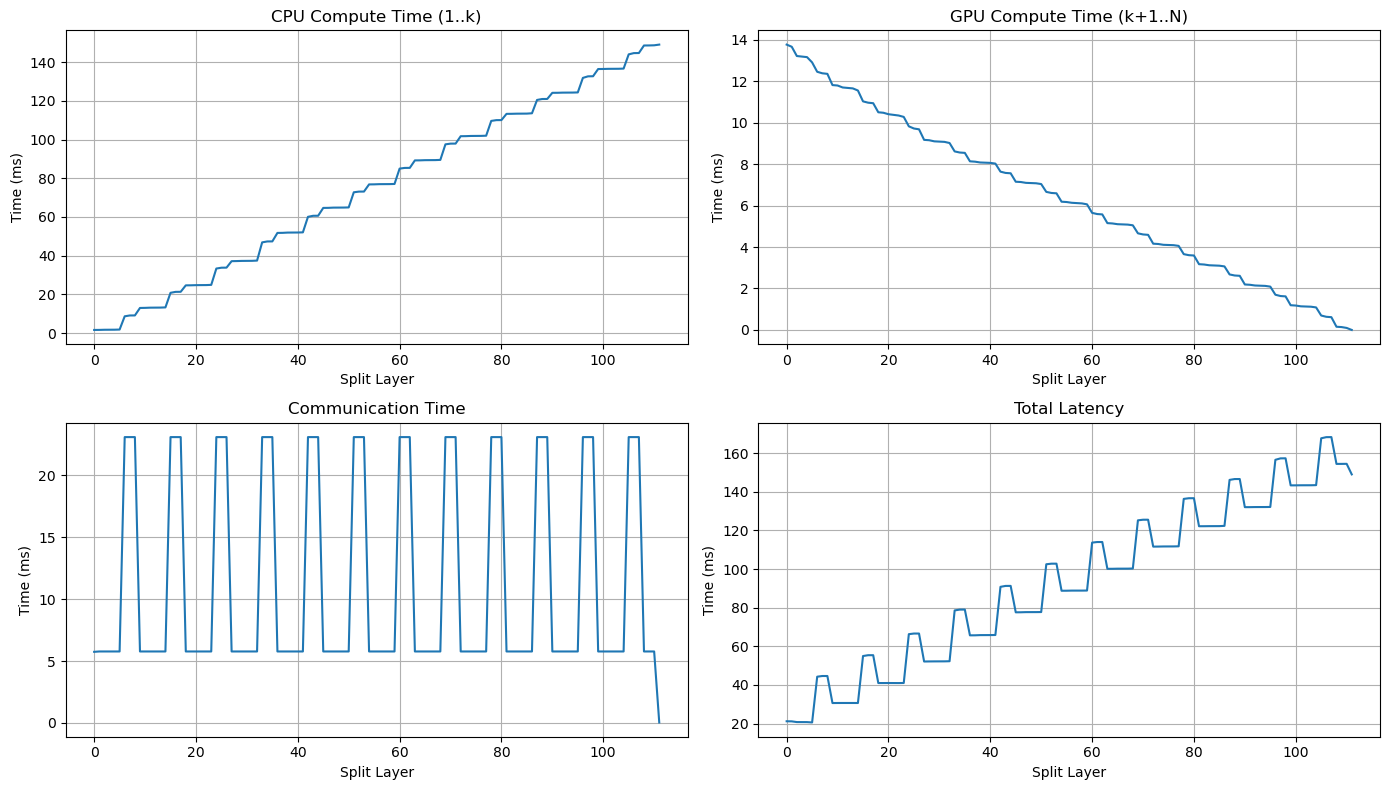

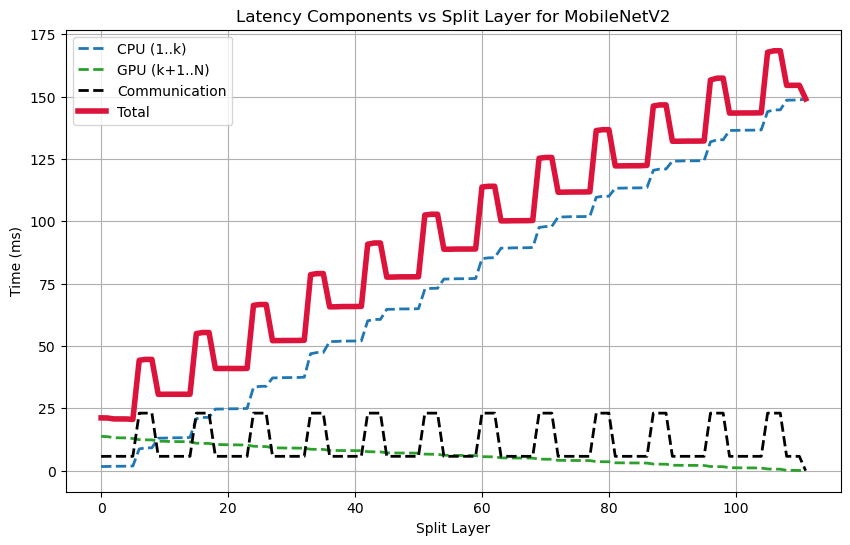

Bandwidth: 100 MB/s	|	Optimal Split Layer: 5


In [15]:
bw = 100  # MB/s
df_split , best_layer = split_latency_analysis(df_cpu, df_gpu, bw)
print(f"Bandwidth: {bw} MB/s",f"|\tOptimal Split Layer: {best_layer}", sep="\t")

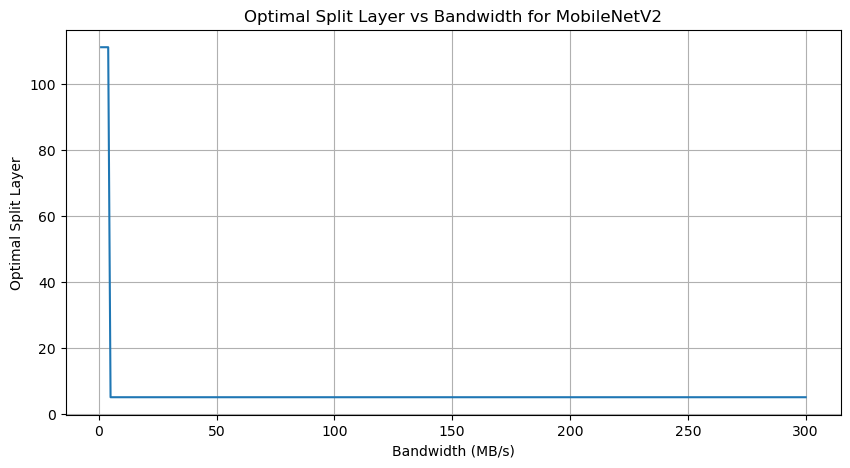

In [12]:
# BW = [1, 10, 25, 50, 75, 100, 236, 237, 300]  # MB/s network bandwidth
BW = [i for i in range(1, 301) if i not in [236, 237]]  # MB/s network bandwidth
best_layers = []
for bw in BW:

    df_split , best_layer = split_latency_analysis(df_cpu, df_gpu, bw, plot=False)
    # print(f"Bandwidth: {bw} MB/s",f"|\tOptimal Split Layer: {best_layer}", sep="\t")
    best_layers.append(best_layer)
plt.figure(figsize=(10,5))
plt.plot(BW, best_layers)
plt.xlabel("Bandwidth (MB/s)")
plt.ylabel("Optimal Split Layer")
plt.title("Optimal Split Layer vs Bandwidth for MobileNetV2")
plt.grid(True)
plt.show()
# 140 Means at the output

Top 5 Predictions:

Samoyed : 0.7997
Pomeranian : 0.0370
keeshond : 0.0172
Japanese spaniel : 0.0057
Eskimo dog : 0.0051


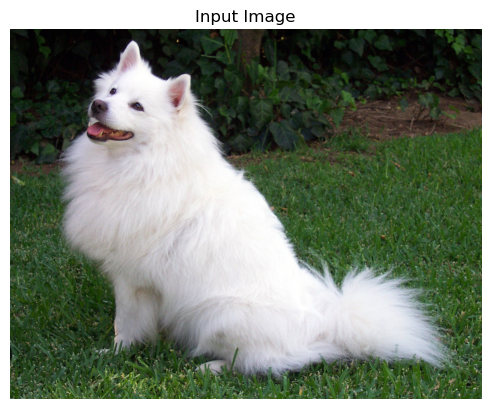

In [13]:
import torch
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import requests
import json
import matplotlib.pyplot as plt

model.eval()

labels_url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
labels = requests.get(labels_url).text.split("\n")

img_path = "image.jpg"   
try:
    image = Image.open(img_path).convert("RGB")
except FileNotFoundError:
    url = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"
    image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

x = transform(image).unsqueeze(0)

x = x.to(next(model.parameters()).device)

with torch.no_grad():
    output = model(x)

prob = torch.nn.functional.softmax(output[0], dim=0)

top5 = torch.topk(prob, 5)

print("Top 5 Predictions:\n")

for idx, p in zip(top5.indices, top5.values):
    print(f"{labels[idx]} : {p.item():.4f}")


plt.imshow(image)
plt.axis("off")
plt.title("Input Image")
plt.show()

In [14]:
# just for reference, lets print a few the labels too
print("A Few ImageNet Classes:")
for i, label in list(enumerate(labels))[20:40]:
    print(f"{i:2d} | {label}")

A Few ImageNet Classes:
20 | water ouzel
21 | kite
22 | bald eagle
23 | vulture
24 | great grey owl
25 | European fire salamander
26 | common newt
27 | eft
28 | spotted salamander
29 | axolotl
30 | bullfrog
31 | tree frog
32 | tailed frog
33 | loggerhead
34 | leatherback turtle
35 | mud turtle
36 | terrapin
37 | box turtle
38 | banded gecko
39 | common iguana
